# KNN on Some Popular Dataset  

## Import the Required Libraries

In [1]:
# Import the Required Libraries
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from knn import KNN

## Iris Dataset

In [2]:
iris = datasets.load_iris()
X, y = iris.data, iris.target

## Plot to Visualize Different Classes

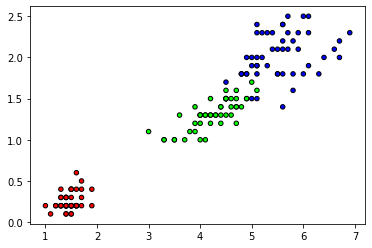

In [3]:
cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])
plt.figure()
plt.scatter(X[:,2],X[:,3], c=y, cmap=cmap, edgecolor='k', s=20)
plt.show()

## Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Create the Model

In [5]:
clf = KNN(k=5)

## Train the Model

In [6]:
clf.fit(X_train, y_train)

## Make the Prediction

In [7]:
predictions = clf.predict(X_test)

## Get Accuracy

In [8]:
acc = np.sum(predictions == y_test) / len(y_test)
print("{:.2f}".format(acc))

0.97


## Make Prediction for New Data Point

In [9]:
clf.predict([[5.8, 2.8, 5.1, 2.4]])

[2]

In [10]:
from sklearn.metrics import accuracy_score

In [11]:
acc = accuracy_score(y_true=y_test,y_pred=predictions)
print("{:.2f}".format(acc))

0.97


## Use Scikit-Learn

In [12]:
from sklearn.neighbors import KNeighborsClassifier
clf_sci = KNeighborsClassifier(n_neighbors=5,p=2)
clf_sci.fit(X_train,y_train)
sci_pred = clf_sci.predict(X_test)
acc_sci = accuracy_score(y_true=y_test,y_pred=sci_pred)
print("{:.2f}".format(acc_sci))

0.97


# MNIST Handwritten Digit Dataset

In [13]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784')

In [14]:
# Access the images
images = mnist['data']
# Access the labels
labels = mnist['target']

## Example of Each Digit 

In [15]:
images=images.values

# Reshape the images to 28x28
images = images.reshape(-1, 28, 28)

# Create a dictionary to store the example images
examples = {}

# Iterate over the images and labels
for i in range(len(images)):
    label = labels[i]
    image = images[i]
    # If the label is not already in the examples dictionary
    if label not in examples:
        examples[label] = image

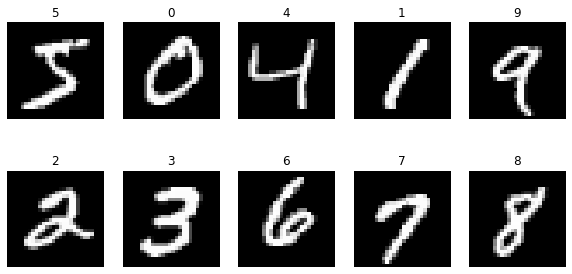

In [16]:
# Plot the example images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()
for i, (label, image) in enumerate(examples.items()):
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.show()

## Train Test Split

In [17]:
X = mnist['data'][:1500]
y = mnist['target'][:1500]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [18]:
X.shape

(1500, 784)

## Create and Train the Model

In [19]:
d_clf = KNN(k=5)
d_clf.fit(X_train.values,y_train.values)

## Make Prediction on Testset

In [20]:
pred = d_clf.predict(X_test.values)

## Get Accuracy

In [21]:
accuracy_score(pred,y_test)

0.8733333333333333

## Making Prediction on New Image

### Function to Load and Preprocess Image

In [26]:
import cv2
def pre_process_image(file_path):
    test_image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    # Format Image
    img_resized = cv2.resize(test_image, (28, 28), interpolation=cv2.INTER_LINEAR)
    img_resized = cv2.bitwise_not(img_resized)
    # Convert the image data to a numpy array
    img_data = np.array(img_resized)
    # Reshape the image data to a 1-D array
    img_data = img_data.reshape(-1)
    return img_data

In [63]:
image_files = ['4_image.jpg','4_image_1.jpg','5_image.jpg']
for item in image_files:
    img_data = pre_process_image(item)
    pred = d_clf.predict([img_data])
    print(f"The Prediction for {item} is {pred}")

The Prediction for 4_image.jpg is ['8']
The Prediction for 4_image_1.jpg is ['8']
The Prediction for 5_image.jpg is ['8']


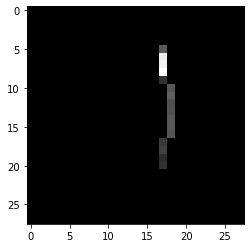

In [45]:
import cv2 
# Load sample image
file = r'1_img.PNG'
test_image = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
# Format Image
img_resized = cv2.resize(test_image, (28, 28), interpolation=cv2.INTER_LINEAR)
# img_resized = cv2.bitwise_not(img_resized)
# Preview reformatted image
plt.imshow(img_resized, cmap='gray')

In [46]:
# Convert the image data to a numpy array
img_data = np.array(img_resized)
# Reshape the image data to a 1-D array
img_data = img_data.reshape(-1)

In [47]:
d_clf.predict([img_data])

['1']